In [163]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from matplotlib import pyplot as plt
import pickle
import skrf as rf

pjoin = os.path.join
pbase = os.path.basename

%load_ext autoreload
%autoreload 2

# import relevant classes from highz_exp
from highz_exp import plotter, reflection_proc
from highz_exp.s_params import S_Params
from highz_exp.spec_class import Spectrum
from highz_exp.fit_temperature import Y_Factor_Thermometer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
# Define macros
LEGEND = ['6" shorted', "8' cable open",'Black body','Ambient temperature load','Noise diode',"8' cable short",'6" open']

nfft = 32768
fs = 3276.8/4
fbins = np.arange(0, nfft//2)
df = fs/nfft
faxis = fbins*df
freq_range = (0, 500) # MHz
faxis_hz = faxis * 1e6

data_path = os.path.expanduser("~/Desktop/High-Z/long_cable")
ant_path = os.path.expanduser("~/Desktop/High-Z/woRelays_wRadials")

### Multiple Reflection Model
If the LNA is connected through coax cable (characteristic 50 $\Omega$) to the any component, there are multiple reflections between the LNA and the component. The total reflection amplitude depends on the S11 of the LNA, the component and the length of the coax cable. The following section takes in the S11 measurements of the LNA and the component (open circuit and short circuit) seen through a cable, and calculates the total reflection coefficient of the LNA. The results are then compared to the S11 of the LNA measured through the same cable.

The total voltage reflection coefficient can be calculated using the following formula:
$$\Gamma_{total} = \Gamma_{comp} \cdot \dfrac{1}{1 - \Gamma_{LNA}}$$

where $\Gamma_{LNA}$ is the voltage reflection coefficient of the LNA, $\Gamma_{comp}$ is the voltage reflection coefficient of the component connected to the cable.

In [165]:
# load all measured S11s
cal_s11 = S_Params(pickle_file=pjoin(data_path, 'all_S11s.pkl'))
cal_s11.keep_freq(25e6, 250e6)

ant_colorcode = {'Ant 1': 'maroon', 'Ant 2': 'olive', 'Ant 3': 'teal', 'Ant 4': 'navy'}
ant_s11 = S_Params(s_params_files=[pjoin(ant_path, f'Ant{n}.s1p') for n in range(1, 5)],
                   labels=[f'Ant {n}' for n in range(1, 5)], 
                   colorcode=ant_colorcode)
ant_s11.resample(np.arange(25e6, 250e6, 1e6))

# calculates voltage reflection coefficient
refle_coeff_dict = {'O.C. Calculated Reflection': reflection_proc.LNA_total_reflection(cal_s11.ntwk_dict["8' cable open"], cal_s11.ntwk_dict["LNA measured"]),
                    'S.C. Calculated Reflection': reflection_proc.LNA_total_reflection(cal_s11.ntwk_dict["8' cable short"], cal_s11.ntwk_dict["LNA measured"])}

vtop = lambda s: np.abs(s)**2

In [166]:
colorcode = {'6" shorted': 'tab:cyan', "8' cable open": 'tab:orange',
             'Black body': 'tab:green','Ambient temperature load': 'tab:red','Noise diode': 'tab:purple',
             "8' cable short": 'tab:blue', '6" open': 'tab:brown'}

In [167]:
split_1 = S_Params(ntwk_dict={key: cal_s11.ntwk_dict[key] for key in ['6" shorted', 'Black body', '6" open']}, colorcode=colorcode)
split_2 = S_Params(ntwk_dict={key: cal_s11.ntwk_dict[key] for key in ["8' cable open", 'Ambient temperature load']}, colorcode=colorcode)
split_3 = S_Params(ntwk_dict={key: cal_s11.ntwk_dict[key] for key in ["8' cable short", 'Noise diode']}, colorcode=colorcode)
# split_1.plot_smith_chart(save_path=pjoin(data_path, 'cal_states_1.png'), title="Calibration States")
# split_2.plot_smith_chart(save_path=pjoin(data_path, 'cal_states_2.png'), title="Calibration States", marker_freqs=[25e6])
# split_3.plot_smith_chart(save_path=pjoin(data_path, 'cal_states_3.png'), title="Calibration States", marker_freqs=[25e6])

### Load measurements of Long Cable Spectra

In [168]:
# load all good cal specs
with open(pjoin(data_path, 'calspec_raw.pkl'), 'rb') as f:
		loaded_spec_states = pickle.load(f)

spectra_to_plot = ['Black body', 'Ambient temperature load', 'Noise diode', "8' cable open", "8' cable short"]
colorcodes = ['tab:green', 'tab:red', 'tab:purple', 'tab:orange', 'tab:blue']
spectra_raw = []
for state, color in zip(spectra_to_plot, colorcodes):
	spec = Spectrum(frequency=faxis_hz,
		spectrum=loaded_spec_states[state]['spectrum'], name=state, colorcode=color)
	spectra_raw.append(spec)

with open(pjoin(data_path, 'second_stage_hotcold.pkl'), 'rb') as f:
	loaded_ss = pickle.load(f)

with open(pjoin(data_path, 'LNA_cal_woHPLP.pkl'), 'rb') as f:
	loaded_LNA_cal = pickle.load(f)

# load cable noise
with open(pjoin(data_path, 'cable_noise_specs.pkl'), 'rb') as f:
  cable_noise = pickle.load(f)
# # load cal specs in dbm
# with open(pjoin(data_path, 'calspec_woHPLP_dbm.pkl'), 'rb') as f:
#   loaded_dbm = pickle.load(f)

with open(pjoin(data_path, 'LNA_temperature.pkl'), 'rb') as f:
  system_thermometer = pickle.load(f)

In [169]:
sc_s11 = cal_s11.ntwk_dict["8\' cable short"]
oc_s11 = cal_s11.ntwk_dict["8\' cable open"]
lna_s11 = cal_s11.ntwk_dict["LNA measured"]
f = sc_s11.f

In [170]:
def total_reflection_coeff(LNA_ntwk, gamma_in: rf.network):
    reflect = (gamma_in.z[:, 0, 0] - LNA_ntwk.z[:, 0, 0])/(gamma_in.z[:, 0, 0] + LNA_ntwk.z[:, 0, 0])
    s = np.zeros((len(reflect), 2, 2), dtype=complex)
    s[:, 1, 0] = reflect
    a_ntwk = rf.Network(f=LNA_ntwk.f, s=s)
    return a_ntwk

def LNA_in(LNA_ntwk, source_ntwk):
    reflect = (LNA_ntwk.z[:, 0, 0] - source_ntwk.z[:, 0, 0])/(LNA_ntwk.z[:, 0, 0] + source_ntwk.z[:, 0, 0])
    s = np.zeros((len(reflect), 2, 2), dtype=complex)
    s[:, 0, 0] = reflect
    a_ntwk = rf.Network(f=LNA_ntwk.f, s=s)
    return a_ntwk

In [171]:
sc_ntwk = total_reflection_coeff(lna_s11, sc_s11)
oc_ntwk = total_reflection_coeff(lna_s11, oc_s11)

In [172]:
sys_BB = Spectrum(frequency=faxis_hz, spectrum=loaded_LNA_cal['LNA-BB']['spectrum'], name='Blackbody', colorcode='tab:green')
sys_ND = Spectrum(frequency=faxis_hz, spectrum=loaded_LNA_cal['LNA-ND']['spectrum'], name='Noise Diode', colorcode='tab:purple')
# plotter.plot_spectra([sys_BB, sys_ND, sys_300K], title='System Response to Blackbody and Noise Diode', ylabel='Power (Arb. dB)',
# system_thermometer.infer_temperature(sys_ND)

### Expected spectra with measured LNA noise and theoretical total reflection coeffcient

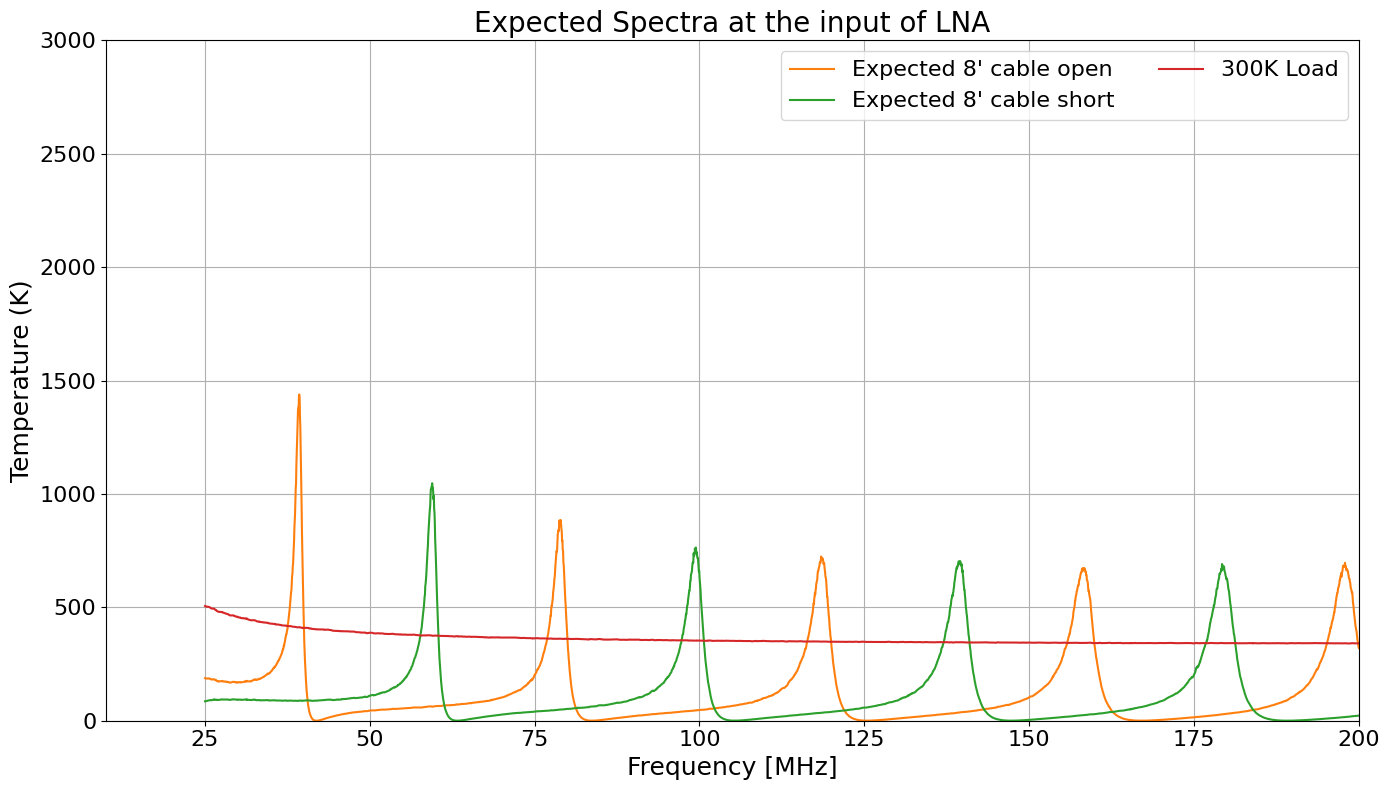

In [195]:
reflection_specs = []
rebin_freq = oc_ntwk.f
system_thermometer = system_thermometer.resample(rebin_freq, inplace=False)
gain = 10**(system_thermometer.g_sys/10)
LNA_noise = system_thermometer.T_dut
sys_noise = system_thermometer.T_sys
for spec in cable_noise.values():
    spec.resample(rebin_freq, inplace=True)

oc_reflection = oc_ntwk.s
sc_reflection = sc_ntwk.s
expected_oc = (LNA_noise * vtop(oc_reflection[:, 1, 0]))
expected_sc = (LNA_noise * vtop(sc_reflection[:, 1, 0]))
oc_spec = Spectrum(frequency=rebin_freq, spectrum=expected_oc, name="Expected 8' cable open", colorcode="tab:orange").despike()
sc_spec = Spectrum(frequency=rebin_freq, spectrum=expected_sc, name="Expected 8' cable short", colorcode="tab:green").despike()
reflection_specs.extend([oc_spec, sc_spec])

load_spec = (sys_noise + np.full(sys_noise.shape, 300))
load_spectrum = Spectrum(frequency=rebin_freq, spectrum=load_spec, name="300K Load", colorcode='tab:red').despike()
reflection_specs.append(load_spectrum)
plotter.plot_spectra(reflection_specs, title="Expected Spectra at the input of LNA", ylabel="Temperature (K)",
                     ls='-', y_range=(0, 3000), freq_range=(10, 200))

In [196]:
s21_sqr = gain * (1-np.abs(lna_s11.s[:, 0, 0])**2)

In [197]:
spike_oc = reflection_proc.count_spikes(oc_spec.s, oc_spec.f, prominence=200, distance=10)
# fig, ax = oc_spec.plot(return_handles=True, y_range=(0, 3000), show_plot=False)
# ax.plot(spike_oc[:, 0]/1e6, spike_oc[:, 1], 'x', label='Detected Spikes')
spike_sc = reflection_proc.count_spikes(sc_spec.s, sc_spec.f, prominence=200, distance=10)

In [198]:
# mask = np.isin(cal_s11.ntwk_dict['8\' cable open'].f, spike_oc[:, 0])
# oc_s11 = cal_s11.ntwk_dict['8\' cable open'][mask]

# mask = np.isin(cal_s11.ntwk_dict['8\' cable short'].f, spike_sc[:, 0])
# sc_s11 = cal_s11.ntwk_dict['8\' cable short'][mask]

# resonance_peaks = S_Params(ntwk_dict={"8' cable open": oc_s11, "8' cable short": sc_s11}, colorcode={'8\' cable open': 'tab:orange', "8\' cable short": 'tab:blue'})
# fig, ax = resonance_peaks.plot_smith_chart(marker='o', ls='', ms=10, radius=1.0)
# fig, ax = ant_s11.plot_smith_chart( fig=fig, ax=ax, ls='-', lw=3, radius=1.0)

# lna = S_Params(ntwk_dict={"LNA measured": cal_s11.ntwk_dict["LNA measured"]}, colorcode={'LNA measured': 'crimson'})
# fig, ax = lna.plot_smith_chart(title="Resonance Peaks for LNA vs. Antenna S11", fig=fig, ax=ax, ls='-', radius=1.0)

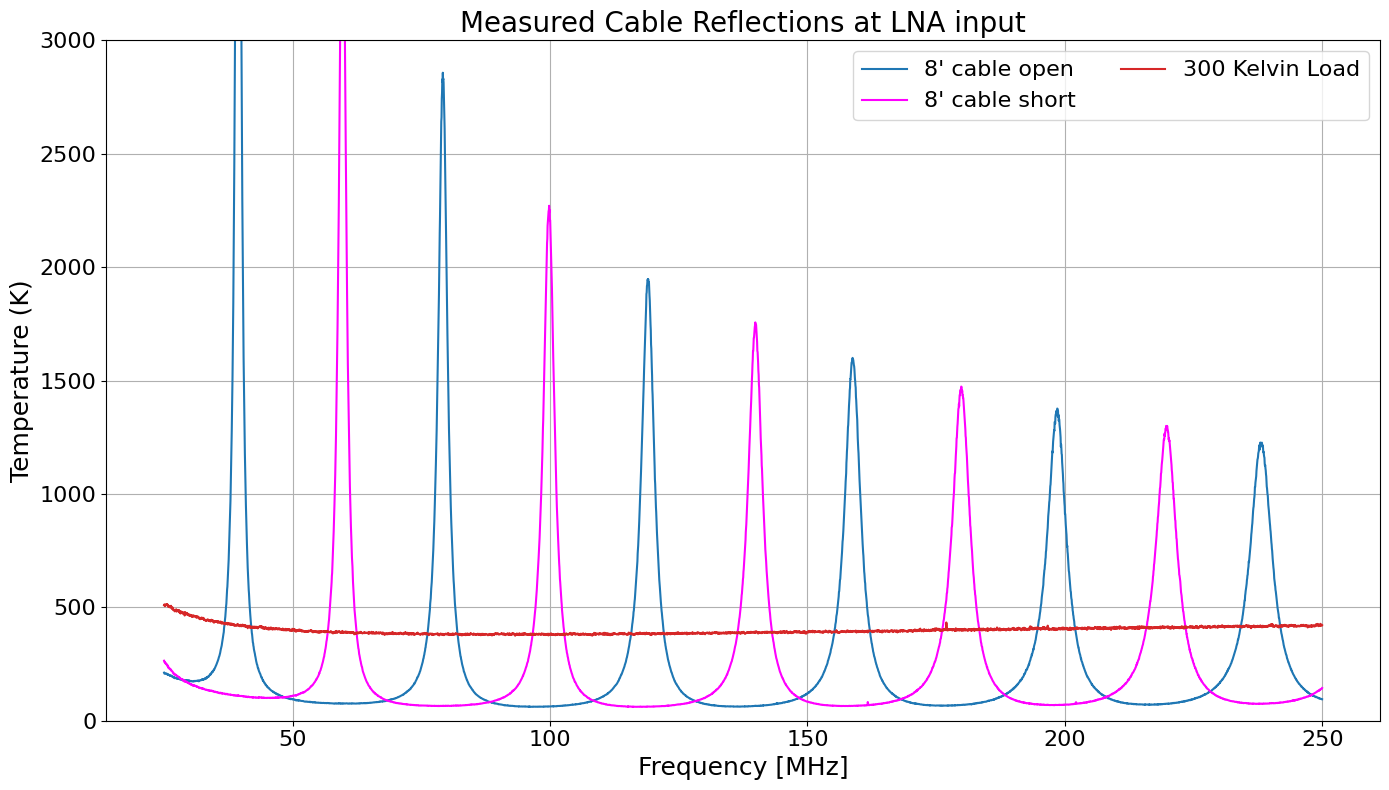

In [199]:
oc_spectra_raw = Spectrum(frequency=faxis_hz, spectrum=loaded_spec_states["8' cable open"]['spectrum'],
                          name="8' cable open", colorcode="tab:blue")
sc_spectra_raw = Spectrum(frequency=faxis_hz, spectrum=loaded_spec_states["8' cable short"]['spectrum'],
                          name="8' cable short", colorcode="magenta")
load_spectra_raw = Spectrum(frequency=faxis_hz, spectrum=loaded_spec_states["Ambient temperature load"]['spectrum'],
                          name="300 Kelvin Load", colorcode="tab:red")

# plotter.plot_spectra([oc_spectra_raw, sc_spectra_raw, load_spectra_raw], title="Raw Spectra of Cable Reflections", ylabel="Power (Arb. mW)",
#                      y_range=(0, 2e9))
for spec in [oc_spectra_raw, sc_spectra_raw, load_spectra_raw]:
    spec.resample(rebin_freq, inplace=True)
load_spectra_raw.s = load_spectra_raw.s / gain 
oc_spectra_raw.s = oc_spectra_raw.s / gain
sc_spectra_raw.s = sc_spectra_raw.s / gain
plotter.plot_spectra([oc_spectra_raw, sc_spectra_raw, load_spectra_raw], title="Measured Cable Reflections at LNA input", ylabel="Temperature (K)",
                     y_range=(0, 3000))

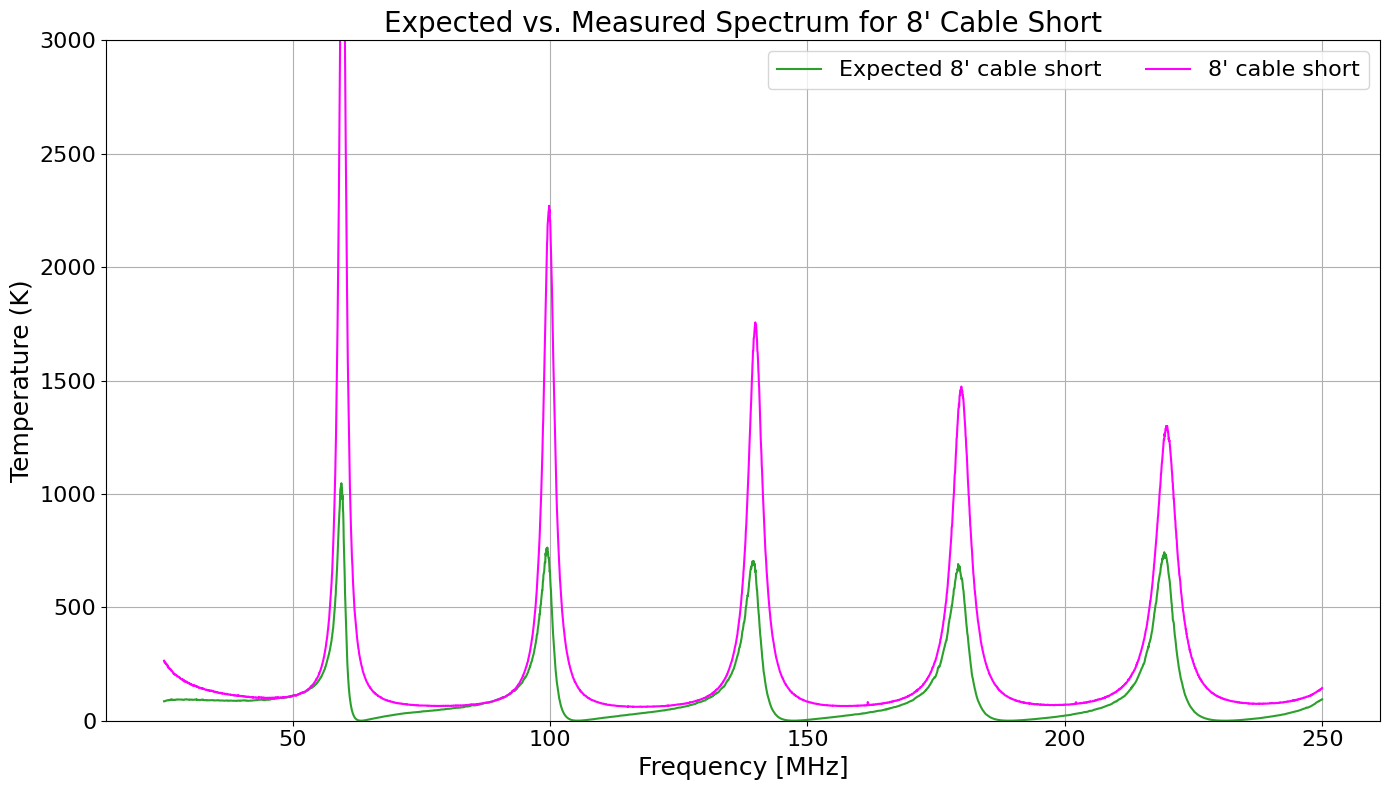

In [202]:
plotter.plot_spectra([sc_spec, sc_spectra_raw], y_range=(0, 3000), title='Expected vs. Measured Spectrum for 8\' Cable Short', 
                     ylabel='Temperature (K)')

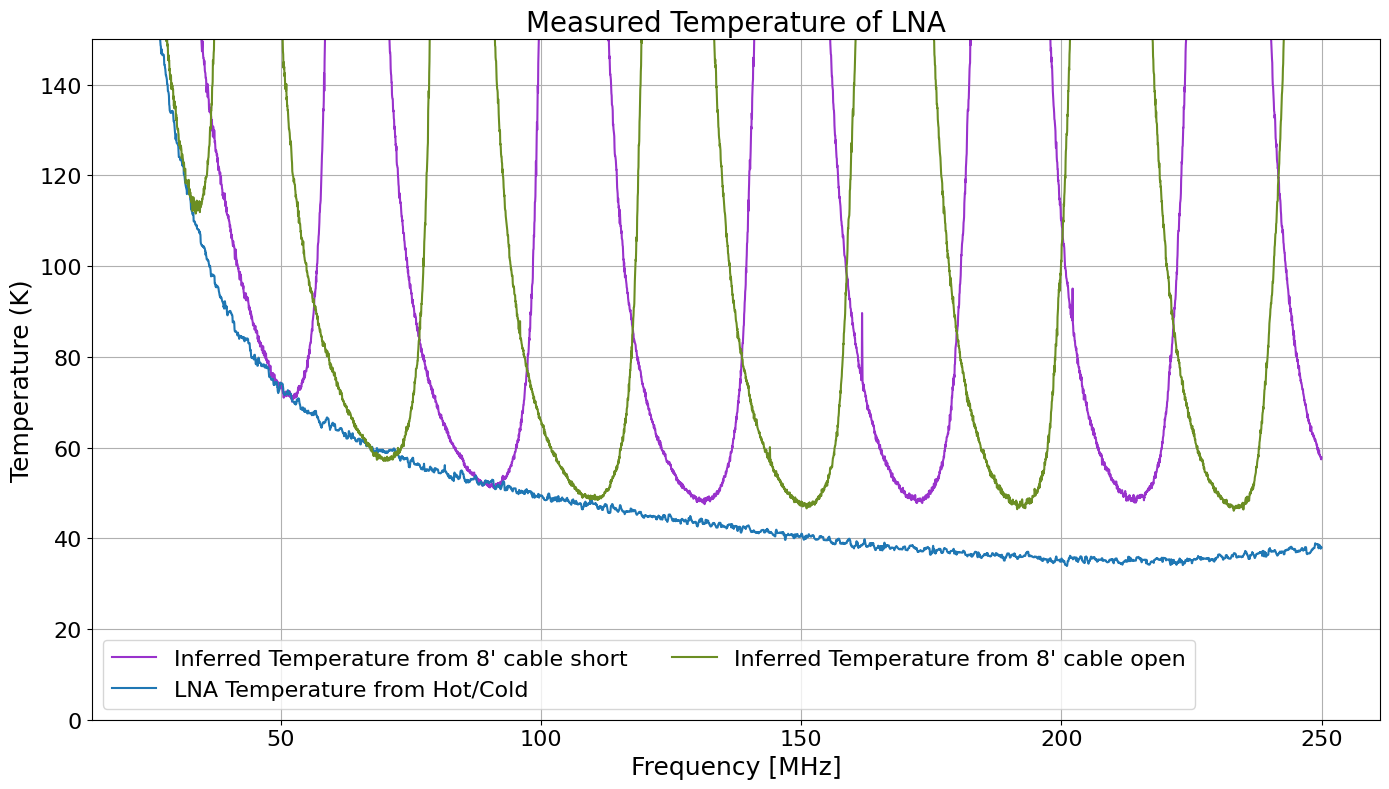

In [158]:
sc_temperature = sc_spectra_raw.s / vtop(sc_ntwk.s[:, 1, 0])
sc_temperature_spec = Spectrum(frequency=rebin_freq, 
                            spectrum=sc_temperature, name="Inferred Temperature from 8' cable short", 
                            colorcode='darkorchid')
fig, ax = sc_temperature_spec.plot(show_plot=False, return_handles=True)
ax.plot(system_thermometer.f/1e6, system_thermometer.T_dut, label='LNA Temperature from Hot/Cold')
ax.legend()

oc_temperature = oc_spectra_raw.s / vtop(oc_ntwk.s[:, 1, 0])
oc_temperature_spec = Spectrum(frequency=rebin_freq, 
                            spectrum=oc_temperature, name="Inferred Temperature from 8' cable open", 
                            colorcode='olivedrab')
oc_temperature_spec.plot(fig=fig, ax=ax, y_range=(0, 150), ylabel='Temperature (K)', title="Measured Temperature of LNA")

In [157]:
reflection_proc.count_spikes(y=-oc_temperature_spec.s, height=-80, x=oc_temperature_spec.f/1e6, prominence=20, distance=10)

array([[ 69.80851648, -57.05257885],
       [110.86352869, -48.44286579],
       [151.06843712, -46.59584279],
       [191.52337607, -46.41270138],
       [233.12845543, -46.0684049 ]])

In [ ]:
gain_corrected = reflection_specs[2].s/load_spectra_raw.s

In [ ]:
for spec in [oc_spectra_raw, sc_spectra_raw, load_spectra_raw]:
    spec.s = spec.s * gain_corrected

# plotter.plot_spectra([oc_spectra_raw, sc_spectra_raw, load_spectra_raw], title="Measured Cable Reflections at LNA input", ylabel="Temperature (K)",
#                      y_range=(0, 3000))

In [ ]:
corrected_oc_spec = Spectrum(frequency=rebin_freq, spectrum=oc_spectra_raw.s*gain_corrected, name="Measured 8' cable open", colorcode="tab:blue")
corrected_sc_spec = Spectrum(frequency=rebin_freq, spectrum=sc_spectra_raw.s*gain_corrected, name="Measured 8' cable short", colorcode="tab:orange")

# plotter.plot_two_spectra_with_residual(corrected_oc_spec, reflection_specs[0], 
#                                        title="Open Circuit Cable Reflection", ylabel="Temperature (K)",
#                                         residual_ylabel="Residual (K)", y_range=(0, 3000), residual_y_range=(-100, 200))
plotter.plot_two_spectra_with_residual(corrected_sc_spec, reflection_specs[1],
                                       title="Short Circuit Cable Reflection", ylabel="Temperature (K)",
                                       residual_ylabel="Residual (K)", y_range=(0, 3000), residual_y_range=(-20, 20))

In [ ]:
lna_temp_sc, measured_f_sc, theory_f = reflection_proc.compute_spike_height_ratios(spike_measured, spike_theory, tolerance=2)

In [ ]:
# Compare with the temperature obtained with y-factor method
with open(pjoin(data_path, 'LNA_temp.pkl'), 'rb') as f:
  lna_temp_Y = pickle.load(f)

In [ ]:
def plot_network_and_temp(network, measured_data,
                          f_min=None, f_max=None,
                          title=None, xlabel='Frequency (Hz)',
                          ylabel='Temperature (K)',
                          network_label='Network',
                          figsize=(10, 6)):
    """
    Plot a network's data and one or more measured temperature datasets.

    Parameters:
    -----------
    network : object
        Network object with attributes .f (frequency array) and .s (S-parameters)
        Assumes .s[:,0,0] contains the data to plot
    measured_data : tuple or list of tuples
        Single tuple (f, temp, label) or list of tuples [(f1, temp1, label1), (f2, temp2, label2), ...]
        Each tuple contains:
        - f: array-like, frequency array
        - temp: array-like, temperature array
        - label: str, label for this dataset
    network_label : str, optional
        Label for network data. Default: 'Network'

    Returns:
    --------
    fig, ax : matplotlib figure and axis objects

    Examples:
    ---------
    # Single measured dataset
    plot_network_and_temp(network, (f1, temp1, 'Measured'))

    # Multiple measured datasets
    plot_network_and_temp(network, [
        (f1, temp1, 'Dataset 1'),
        (f2, temp2, 'Dataset 2'),
        (f3, temp3, 'Dataset 3')
    ])
    """
    # Get network data
    net_f = network.f
    net_data = network.s[:, 0, 0]

    # Apply frequency filters to network data
    net_mask = np.ones(len(net_f), dtype=bool)
    if f_min is not None:
        net_mask &= (net_f >= f_min)
    if f_max is not None:
        net_mask &= (net_f <= f_max)

    # Normalize measured_data to list of tuples
    if isinstance(measured_data, tuple) and len(measured_data) == 3:
        # Single dataset passed as tuple
        measured_data = [measured_data]

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot network data as line
    ax.plot(net_f[net_mask], net_data[net_mask], label=network_label)

    # Plot each measured dataset as dots with different colors
    for meas_f, meas_temp, meas_label in measured_data:
        # Apply frequency filters to this measured dataset
        meas_mask = np.ones(len(meas_f), dtype=bool)
        if f_min is not None:
            meas_mask &= (meas_f >= f_min)
        if f_max is not None:
            meas_mask &= (meas_f <= f_max)

        # Plot measured data as dots (color will be auto-assigned by matplotlib)
        ax.plot(meas_f[meas_mask], meas_temp[meas_mask], 'o',
                label=meas_label, markersize=7)

    ax.tick_params(axis='both', labelsize=16, which='major')

    # Set labels and title
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    if title:
        ax.set_title(title, fontsize=18)

    ax.legend(fontsize=18)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax

In [ ]:
# see the peaks in theory versus measured
print("############## Gain in open circuit cable reflection ##############")
spike_theory = file_load.count_spikes(np.abs(refle_coeff['O.C. Calculated Reflection'].s[:,0,0]), refle_coeff['O.C. Calculated Reflection'].f/1e6, distance=100, height=4, print_table=True)
print("############## Measured open circuit cable reflection ##############")
spike_measured = file_load.count_spikes(np.abs(oc_measured.s[:,0,0]), oc_measured.f/1e6, distance=300, height=500, threshold=10, print_table=True)
lna_temp_oc, measured_f_oc, theory_f = reflection_proc.compute_spike_height_ratios(spike_measured, spike_theory, tolerance=2)

In [ ]:
# Plot with multiple measured datasets
fig, ax = plot_network_and_temp(
    lna_temp_Y,
    [
        (measured_f_oc, lna_temp_oc, 'From Cable Reflections (Open Circuit)'),
        (measured_f_sc, lna_temp_sc, 'From Cable Reflections (Short Circuit)')
    ],
    f_min=18,
    title='LNA Temperature',
    xlabel='Frequency (MHz)',
    ylabel='Temperature (K)',
    network_label='From Hot-Cold method'
)

plt.savefig(pjoin(plot_path, 'LNA_temp_compare.png'))

In [ ]:
from scipy.optimize import curve_fit
import skrf as rf

def exp_mod(f, A, C, beta, gamma):
    return A * np.exp(-beta * f + C) + gamma/f

def poly_mod(f, a):
    return a

def flicker_mod(f, a, b):
    return a/f + b

def fit_s11_spectrum(measured_data: rf.Network, theory_data: rf.Network, gain_func, extra_func, p0, n_gain_params):
    """
    Fit the measured S11 spectrum to a model of the form:
        corrected_mag = |theory_s11 * gain_func(f, ...) + extra_func(f, ...)|

    Parameters:
    - measured_data (rf.Network)
    - theory_data (rf.Network)
    - gain_func (callable): multiplicative correction, function of form (f, *params)
    - extra_func (callable): additive correction, function of form (f, *params)
    - p0 (list): initial guess for all params (gain + extra)
    - n_gain_params (int): number of parameters in gain_func

    Returns:
    - popt (list): best-fit parameters
    - pcov (2D array): covariance matrix
    - corrected_ntwk (rf.Network): corrected theory spectrum
    """

    mask = (np.isfinite(theory_data.s[:, 0, 0]) &
     np.isfinite(measured_data.s[:, 0, 0])
    )

    theory_data = theory_data[mask]
    measured_data = measured_data[mask]

    if not np.allclose(measured_data.f, theory_data.f):
        raise ValueError("Frequency grids must match.")

    f = measured_data.f
    f_GHz = f / 1e9  # for numerical stability

    theory_s11 = theory_data.s[:, 0, 0]
    theory_phase = np.angle(theory_s11)
    measured_mag = np.abs(measured_data.s[:, 0, 0])

    # Fit wrapper
    def fit_func(f, *params):
        gain_params = params[:n_gain_params]
        extra_params = params[n_gain_params:]
        model = theory_s11 * gain_func(f, *gain_params) + extra_func(f, *extra_params)
        return np.abs(model)

    # Fit
    popt, pcov = curve_fit(fit_func, f_GHz, measured_mag, p0=p0)

    # Apply best-fit model
    gain_params_opt = popt[:n_gain_params]
    extra_params_opt = popt[n_gain_params:]
    corrected_s11 = theory_s11 * gain_func(f_GHz, *gain_params_opt) + extra_func(f_GHz, *extra_params_opt)

    # Return new Network
    corrected_ntwk = rf.Network()
    corrected_ntwk.f = theory_data.f
    corrected_ntwk.s = corrected_s11.reshape(-1, 1, 1)
    corrected_ntwk.z0 = theory_data.z0
    corrected_ntwk.frequency = theory_data.frequency

    return popt, pcov, corrected_ntwk, mask

def evaluate_noise_function(frequencies, gain_func, popt):
    """
    Evaluate the gain function over given frequencies using best-fit parameters.

    Parameters:
    - frequencies (1D array): in Hz
    - gain_func (callable): the gain function (f_GHz, *params) -> gain
    - popt (list): list of all fitted parameters (gain)

    Returns:
    - f_MHz (1D array): frequency array in GHz
    - gain_values (1D array): evaluated gain function
    """
    f_GHz = frequencies / 1e9
    f_MHz = frequencies / 1e6

    # Filter frequencies above 20 MHz
    freq_mask = f_MHz > 30
    f_MHz_filtered = f_MHz[freq_mask]
    f_GHz_filtered = f_GHz[freq_mask]

    gain_values = gain_func(f_GHz_filtered, *popt)

    return rf.Network(f=f_GHz_filtered*1e9, s=gain_values.reshape(-1, 1, 1))

In [ ]:
# Interpolate again to get the set of frequencies
theory_oc_ntwk = theory_oc_ntwk.interpolate(oc_measured.f)
theory_sc_ntwk = theory_sc_ntwk.interpolate(sc_measured.f)

In [ ]:
popt, pcov, corr_ntwk, mask = fit_s11_spectrum(oc_measured, theory_oc_ntwk, gain_func=exp_mod, extra_func=poly_mod,
                                         p0=[14, 0.1, 1, 0.01, 0.01], n_gain_params=4)
oc_theory_measured = {"Measured Reflection Power": oc_measured[mask],
                      "Fitted Reflection Power": corr_ntwk}
popt[0], popt[1], popt[2], popt[3], popt[4]

In [ ]:
def plot_measured_vs_fitted(ntwk_dict, scale='linear', save_plot=True, save_path=None, ylabel='Magnitude', title='Measured vs Fitted Spectrum', show_residual=False, show_bottom_panel=True):
    """
    Plot magnitude for measured and fitted spectrum data, and optionally a ratio panel (measured/fitted) or residual panel.

    Parameters:
    - ntwk_dict (dict): {'measured': skrf.Network, 'fitted': skrf.Network}
    - show_residual (bool): If True, show residual (measured - fitted). If False, show ratio (fitted/measured).
    - show_bottom_panel (bool): Whether to show the bottom panel (ratio or residual).
    """
    assert len(ntwk_dict) == 2, "ntwk_dict must contain exactly two items: measured and fitted."
    keys = list(ntwk_dict.keys())
    measured_ntwk = ntwk_dict[keys[0]]
    fitted_ntwk = ntwk_dict[keys[1]]

    freq = measured_ntwk.f
    spec_measured = measured_ntwk.s[:, 0, 0]
    spec_fitted = fitted_ntwk.s[:, 0, 0]

    mag_measured = 20 * np.log10(np.abs(spec_measured)) if scale == 'log' else np.abs(spec_measured)
    mag_fitted = 20 * np.log10(np.abs(spec_fitted)) if scale == 'log' else np.abs(spec_fitted)

    nrows = 2 if show_bottom_panel else 1
    fig, axes = plt.subplots(nrows=nrows, figsize=(12, 8), sharex=True)
    if nrows == 1:
        axes = [axes]  # Make it iterable for consistency

    ax_mag = axes[0]

    ax_mag.plot(freq / 1e6, mag_measured, label=f'{keys[0]}', color='C0')
    ax_mag.plot(freq / 1e6, mag_fitted, label=f'{keys[1]}', color='C1', linestyle='--')
    ax_mag.set_ylabel(ylabel, fontsize=20)
    ax_mag.legend(loc='best', fontsize=18)
    ax_mag.grid(True)
    ax_mag.tick_params(axis='both', which='major', labelsize=18)

    if show_bottom_panel:
        ax_bottom = axes[1]

        if show_residual:
            residual = mag_measured - mag_fitted
            ax_bottom.plot(freq / 1e6, residual, color='C2')
            ax_bottom.axhline(0, color='red', linestyle='-', linewidth=1.5, label='residual = 0')
            ax_bottom.set_ylabel('Residual (Measured - Theory)', fontsize=14)
        else:
            ratio = mag_measured / mag_fitted
            ax_bottom.plot(freq / 1e6, 1 / ratio, color='C2')
            ax_bottom.axhline(1, color='red', linestyle='-', linewidth=1.5, label='measured/theory = 1')
            ax_bottom.set_ylabel('Measured/Theory', fontsize=18)

        ax_bottom.set_xlabel('Frequency [MHz]', fontsize=18)
        ax_bottom.grid(True)
        ax_bottom.legend(loc='best')
    else:
        ax_mag.set_xlabel('Frequency [MHz]', fontsize=20)

    fig.suptitle(title, fontsize=20)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save_plot:
        if save_path is not None:
            plt.savefig(save_path)
        else:
            print("! Save path not entered.")

    plt.show()


In [ ]:
plot_measured_vs_fitted(oc_theory_measured, scale='linear', save_plot=True, save_path=pjoin(plot_path, 'OC_fitted_vs_measured'),
                       ylabel='Noise Temperature (K)', title=None, show_bottom_panel=False)
LNA_noise_oc = evaluate_noise_function(corr_ntwk.f, exp_mod, popt[:4])

In [ ]:
popt, pcov, corr_ntwk, mask = fit_s11_spectrum(sc_measured, theory_sc_ntwk, gain_func=exp_mod, extra_func=poly_mod,
                                               p0=[20, 0.1, 1, 0.01, 0.01], n_gain_params=4)
sc_theory_measured = {"Measured Reflection Power": sc_measured[mask],
                      "Fitted Reflection Power": corr_ntwk}
popt[0], popt[1], popt[2], popt[3], popt[4]

In [ ]:
plot_measured_vs_fitted(sc_theory_measured, scale='linear', save_plot=True, show_bottom_panel=False, save_path=pjoin(plot_path, 'SC_fitted_vs_measured'),
                       ylabel='Noise Temperature (K)', title=None)
LNA_noise_sc = evaluate_noise_function(corr_ntwk.f, exp_mod, popt[:4])

In [ ]:
spec_plot.plot_network_data({"LNA Noise Modelled from OC": LNA_noise_oc, "LNA Noise Modelled from SC": LNA_noise_sc}, save_plot=True, show_phase=False, save_path=pjoin(spec_base_path, 'plots', 'LNA_Noise_Modelled'),
                            ylabel='Noise Temperature (K)', title="LNA Noise from Fitting Cable Reflections")